In [3]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import SystemMessage, ToolMessage, BaseMessage, AIMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
from datetime import datetime
from langchain_google_community import CalendarToolkit, GmailToolkit
from langchain_google_community.calendar.utils import get_google_credentials

# Get OAuth credentials
credentials = get_google_credentials(
    token_file="token.json",
    scopes=["https://www.googleapis.com/auth/calendar"],
    client_secrets_file="credentials.json",
)


In [4]:
load_dotenv(override=True)

True

In [5]:
gmail_toolkit = GmailToolkit(credentials=credentials)
calendar_toolkit = CalendarToolkit(credentials=credentials)
tools = calendar_toolkit.get_tools() + gmail_toolkit.get_tools()

In [6]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [7]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
).bind_tools(tools)

In [8]:
def llm_node(state: AgentState) -> AgentState:
    # print("\n\nSTATE: ", state)
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    system_prompt = SystemMessage(
        content=f"You are a helpful assistant that answers the user's question accurately. Current time: {current_time}"
    )
    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

In [9]:
def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "tool_call"

In [10]:
graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)

tool_node = ToolNode(tools = tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("llm")
graph.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tool_call": "tools",
        "end": END
    }
)

graph.add_edge("tools", "llm")
agent = graph.compile()

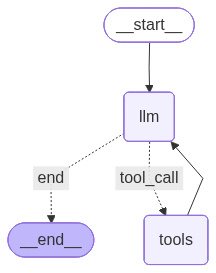

In [11]:
agent

In [12]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [13]:
inputs = {"messages": [("user", "Create a draft email to Ahmed about tomorrow’s meeting.")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Create a draft email to Ahmed about tomorrow’s meeting.


================================== Ai Message ==================================
Tool Calls:
  create_gmail_draft (call_mOaU8AgNmdNc1uXToA12jXxp)
 Call ID: call_mOaU8AgNmdNc1uXToA12jXxp
  Args:
    message: Hi Ahmed,\n\nI hope this message finds you well. I wanted to remind you about our meeting scheduled for tomorrow. Please let me know if you have any topics you would like to discuss.\n\nLooking forward to our conversation!\n\nBest regards,\n[Your Name]
    to: ['ahmed@example.com']
    subject: Reminder: Meeting Tomorrow


================================= Tool Message =================================
Name: create_gmail_draft

Draft created. Draft Id: r-5233350776061952019


================================== Ai Message ==================================

I have created a draft email to Ahmed about tomorrow's meeting. You can review and send it when you're ready.


In [14]:
inputs = {"messages": [("user", "“Send an email to thehamzalog@gmail.com saying the report is ready.”")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

“Send an email to thehamzalog@gmail.com saying the report is ready.”


================================== Ai Message ==================================
Tool Calls:
  send_gmail_message (call_8s831iD9rQ6XhwIiw7ZeYK1m)
 Call ID: call_8s831iD9rQ6XhwIiw7ZeYK1m
  Args:
    message: The report is ready.
    to: thehamzalog@gmail.com
    subject: Report Ready


================================= Tool Message =================================
Name: send_gmail_message

Message sent. Message Id: 19ee015fcf8c8851


================================== Ai Message ==================================

The email has been sent to thehamzalog@gmail.com, informing them that the report is ready.


In [17]:
inputs = {"messages": [("user", "Tell me about email received from Jhangir Ahmad")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Tell me about email received from Jhangir Ahmad


================================== Ai Message ==================================
Tool Calls:
  search_gmail (call_2TzPXsQojOPOno9PSrBPdXSJ)
 Call ID: call_2TzPXsQojOPOno9PSrBPdXSJ
  Args:
    query: from:Jhangir Ahmad
    max_results: 5


================================= Tool Message =================================
Name: search_gmail

[{"id": "19e91ae295d00fc8", "threadId": "19e91ae295d00fc8", "snippet": "Jhangir Ahmad shared a spreadsheet Jhangir Ahmad (jhangirahmad551@gmail.com) has invited you to edit the following spreadsheet: Recording Sheets 1 sheet per person Recording Dataset Open Does this item", "body": "I've shared an item with you:\r\n\r\nRecording Dataset\r\nhttps://docs.google.com/spreadsheets/d/1CAR7gIpMc3n4IhWc0AIY6onXi8Xt0XR5vRkxQH_NmnQ/edit?usp=sharing&ts=6a2132ba\r\n\r\nIt's not an attachment – it's stored online. To open this item, just click  \r\nthe link above.\r\n\r\nRecording Sheets\r\n1 sheet per person\r\n", "subject": "=?UTF-8?Q?Spreadsheet_shared_with_you=3A_=E2=80=98Recording_Dataset=E2=80=99?=", "sender": "\"Jhangir Ahmad (via Google Sheets)\" <drive-shares-dm-noreply@google.com>"}, {"id": "19e91ad7ccc8a21a", "threadId": "19e91ad7ccc8a21a", "snippet": "Jhangir Ahmad shared a spreadsheet 

================================== Ai Message ==================================

Here are the recent emails received from Jhangir Ahmad:

1. **Email Subject:** Spreadsheet shared with you: ‘Recording Dataset’
   - **Sender:** Jhangir Ahmad (via Google Sheets) <drive-shares-dm-noreply@google.com>
   - **Snippet:** Jhangir Ahmad shared a spreadsheet. He has invited you to edit the following spreadsheet: Recording Sheets 1 sheet per person.
   - **Body:** 
     ```
     I've shared an item with you:
     
     Recording Dataset
     https://docs.google.com/spreadsheets/d/1CAR7gIpMc3n4IhWc0AIY6onXi8Xt0XR5vRkxQH_NmnQ/edit?usp=sharing&ts=6a2132ba
     
     It's not an attachment – it's stored online. To open this item, just click the link above.
     
     Recording Sheets
     1 sheet per person
     ```

2. **Email Subject:** Spreadsheet shared with you: ‘Recording Dataset’
   - **Sender:** Jhangir Ahmad (via Google Sheets) <drive-shares-dm-noreply@google.com>
   - **Snippet:** Jhangir A

In [16]:


inputs = {"messages": [("user", "Find a free 1-hour slot tomorrow afternoon and schedule a project review meeting.")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Find a free 1-hour slot tomorrow afternoon and schedule a project review meeting.


================================== Ai Message ==================================
Tool Calls:
  get_calendars_info (call_HRo3hSCtdcguY0AiDHYfYW01)
 Call ID: call_HRo3hSCtdcguY0AiDHYfYW01
  Args:


================================= Tool Message =================================
Name: get_calendars_info

[{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}, {"id": "en-gb.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}, {"id": "en.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}]


================================== Ai Message ==================================
Tool Calls:
  search_events (call_9lbcbGMY9DZ4ZrhcGl6c6Bi5)
 Call ID: call_9lbcbGMY9DZ4ZrhcGl6c6Bi5
  Args:
    calendars_info: [{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}]
    min_datetime: 2026-06-19 12:00:00
    max_datetime: 2026-06-19 17:00:00
    max_results: 10


================================= Tool Message =================================
Name: search_events

[]


...

================================== Ai Message ==================================
Tool Calls:
  search_events (call_f5VWsDJeyyhUpHzaDiszKsyL)
 Call ID: call_f5VWsDJeyyhUpHzaDiszKsyL
  Args:
    calendars_info: [{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}]
    min_datetime: 2026-06-19 12:00:00
    max_datetime: 2026-06-19 17:00:00
    max_results: 10


================================= Tool Message =================================
Name: search_events

[]


================================== Ai Message ==================================
Tool Calls:
  create_calendar_event (call_2coLzclOxaZdK2M5BAfuvYbm)
 Call ID: call_2coLzclOxaZdK2M5BAfuvYbm
  Args:
    summary: Project Review Meeting
    start_datetime: 2026-06-19 12:00:00
    end_datetime: 2026-06-19 13:00:00
    timezone: Asia/Karachi


================================= Tool Message =================================
Name: create_calendar_event

Event created: https://www.google.com/calendar/event?eid=bXI2Y2cxMTlodmY4dnRzZGRvN2RnNmluNGsgYWxpaGFteGE1NDEyQG0


================================== Ai Message ==================================

I have scheduled the **Project Review Meeting** for tomorrow, June 19, 2026, from **12:00 PM to 1:00 PM** (Asia/Karachi time). You can view the event [here](https://www.google.com/calendar/event?eid=bXI2Y2cxMTlodmY4dnRzZGRvN2RnNmluNGsgYWxpaGFteGE1NDEyQG0).


In [17]:
inputs = {"messages": [("user", "Book a meeting with Ahmed next week.")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Book a meeting with Ahmed next week.


================================== Ai Message ==================================
Tool Calls:
  get_calendars_info (call_AgA8FEBk4B94rijIVK12aP9g)
 Call ID: call_AgA8FEBk4B94rijIVK12aP9g
  Args:


================================= Tool Message =================================
Name: get_calendars_info

[{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}, {"id": "en-gb.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}, {"id": "en.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}]


================================== Ai Message ==================================
Tool Calls:
  get_current_datetime (call_VOQfjXn9qFP2duAjproQHcDt)
 Call ID: call_VOQfjXn9qFP2duAjproQHcDt
  Args:
    calendar_id: alihamxa5412@gmail.com


================================= Tool Message =================================
Name: get_current_datetime

Time zone: Asia/Karachi, Date and time: 2026-06-18 09:52:47


================================== Ai Message ==================================
Tool Calls:
  create_calendar_event (call_SZn1AhFSkfOaSq9YBsb97rw9)
 Call ID: call_SZn1AhFSkfOaSq9YBsb97rw9
  Args:
    summary: Meeting with Ahmed
    start_datetime: 2026-06-25 10:00:00
    end_datetime: 2026-06-25 11:00:00
    timezone: Asia/Karachi
    attendees: ['ahmed@example.com']


================================= Tool Message =================================
Name: create_calendar_event

Event created: https://www.google.com/calendar/event?eid=NjVnYmFucWxwaDhiY3ZrNGVlbTU0YWZnb28gYWxpaGFteGE1NDEyQG0


================================== Ai Message ==================================

I have scheduled a meeting with Ahmed for June 25, 2026, from 10:00 AM to 11:00 AM (Asia/Karachi time). You can view the event [here](https://www.google.com/calendar/event?eid=NjVnYmFucWxpaDhiY3ZrNGVlbTU0YWZnb28gYWxpaGFteGE1NDEyQG0).


In [18]:
inputs = {"messages": [("user", "What meetings do I have tomorrow?")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What meetings do I have tomorrow?


================================== Ai Message ==================================
Tool Calls:
  get_calendars_info (call_ujTc21AZHJWnsacB4kvavKSs)
 Call ID: call_ujTc21AZHJWnsacB4kvavKSs
  Args:


================================= Tool Message =================================
Name: get_calendars_info

[{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}, {"id": "en-gb.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}, {"id": "en.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}]


================================== Ai Message ==================================
Tool Calls:
  search_events (call_ch2L5t4PMzuJIt98FaC5EZf0)
 Call ID: call_ch2L5t4PMzuJIt98FaC5EZf0
  Args:
    calendars_info: [{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}]
    min_datetime: 2026-06-19 00:00:00
    max_datetime: 2026-06-19 23:59:59


================================= Tool Message =================================
Name: search_events

[{"id": "5u7hjc0j7gqfvd02hglkcmulcv_20260619T051500Z", "htmlLink": "https://www.google.com/calendar/event?eid=NXU3aGpjMGo3Z3FmdmQwMmhnbGtjbXVsY3ZfMjAyNjA2MTlUMDUxNTAwWiBhbGloYW14YTU0MTJAbQ", "summary": " Internal: DSM", "creator": "abdullah.rafique@hstadvantage.com", "organizer": "abdullah.rafique@hstadvantage.com", "start": "2026-06-19T10:15:00+05:00", "end": "2026-06-19T10:45:00+05:00"}, {"id": "mr6cg119hvf8vtsddo7dg6in4k", "htmlLink": "https://www.google.com/calendar/event?eid=bXI2Y2cxMTlodmY4dnRzZGRvN2RnNmluNGsgYWxpaGFteGE1NDEyQG0", "summary": "Project Review Meeting", "creator": "alihamxa5412@gmail.com", "organizer": "alihamxa5412@gmail.com", "start": "2026-06-19T12:00:00+05:00", "end": "2026-06-19T13:00:00+05:00"}]


================================== Ai Message ==================================

You have the following meetings scheduled for tomorrow, June 19, 2026:

1. **Internal: DSM**
   - **Time:** 10:15 AM - 10:45 AM (PKT)
   - **Organizer:** Abdullah Rafique
   - [Join Meeting](https://www.google.com/calendar/event?eid=NXU3aGpjMGo3Z3FmdmQwMmhnbGtjbXVsY3ZfMjAyNjA2MTlUMDUxNTAwWiBhbGloYW14YTU0MTJAbQ)

2. **Project Review Meeting**
   - **Time:** 12:00 PM - 1:00 PM (PKT)
   - **Organizer:** Ali Hamza
   - [Join Meeting](https://www.google.com/calendar/event?eid=bXI2Y2cxMTlodmY4dnRzZGRvN2RnNmluNGsgYWxpaGFteGE1NDEyQG0)

Let me know if you need any further assistance!


In [13]:
inputs = {"messages": [("user", "Do I have any meetings on Friday?")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Do I have any meetings on Friday?


================================== Ai Message ==================================
Tool Calls:
  get_calendars_info (call_rSqcdYn916iGWaySy4MQTqWF)
 Call ID: call_rSqcdYn916iGWaySy4MQTqWF
  Args:


================================= Tool Message =================================
Name: get_calendars_info

[{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}, {"id": "en-gb.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}, {"id": "en.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}]


================================== Ai Message ==================================
Tool Calls:
  search_events (call_TIWPIzNouVRN3vRZnmL01R6h)
 Call ID: call_TIWPIzNouVRN3vRZnmL01R6h
  Args:
    calendars_info: [{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}]
    min_datetime: 2026-06-23 00:00:00
    max_datetime: 2026-06-23 23:59:59


================================= Tool Message =================================
Name: search_events

[{"id": "5u7hjc0j7gqfvd02hglkcmulcv_20260623T051500Z", "htmlLink": "https://www.google.com/calendar/event?eid=NXU3aGpjMGo3Z3FmdmQwMmhnbGtjbXVsY3ZfMjAyNjA2MjNUMDUxNTAwWiBhbGloYW14YTU0MTJAbQ", "summary": " Internal: DSM", "creator": "abdullah.rafique@hstadvantage.com", "organizer": "abdullah.rafique@hstadvantage.com", "start": "2026-06-23T10:15:00+05:00", "end": "2026-06-23T10:45:00+05:00"}]


================================== Ai Message ==================================

You have a meeting scheduled on Friday, June 23, 2026. Here are the details:

- **Meeting Title:** Internal: DSM
- **Start Time:** 10:15 AM (PKT)
- **End Time:** 10:45 AM (PKT)
- **Organizer:** [abdullah.rafique@hstadvantage.com](mailto:abdullah.rafique@hstadvantage.com)

You can view the meeting [here](https://www.google.com/calendar/event?eid=NXU3aGpjMGo3Z3FmdmQwMmhnbGtjbXVsY3ZfMjAyNjA2MjNUMDUxNTAwWiBhbGloYW14YTU0MTJAbQ).


In [14]:

inputs = {"messages": [("user", "tell me about my tomorrows meetings")]}
print_stream(agent.stream(inputs, stream_mode="values"))

================================ Human Message =================================

tell me about my tomorrows meetings


================================== Ai Message ==================================
Tool Calls:
  get_calendars_info (call_Zq2k1NZKSHMwUzNu15xFuDcm)
 Call ID: call_Zq2k1NZKSHMwUzNu15xFuDcm
  Args:


================================= Tool Message =================================
Name: get_calendars_info

[{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}, {"id": "en-gb.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}, {"id": "en.pk#holiday@group.v.calendar.google.com", "summary": "Holidays in Pakistan", "timeZone": "Asia/Karachi"}]


================================== Ai Message ==================================
Tool Calls:
  search_events (call_qr1gljBq764g7qBqgqVBSHVy)
 Call ID: call_qr1gljBq764g7qBqgqVBSHVy
  Args:
    calendars_info: [{"id": "alihamxa5412@gmail.com", "summary": "alihamxa5412@gmail.com", "timeZone": "Asia/Karachi"}]
    min_datetime: 2026-06-19 00:00:00
    max_datetime: 2026-06-19 23:59:59


================================= Tool Message =================================
Name: search_events

[{"id": "4mr44spe9q46n01gku3ppo740c", "htmlLink": "https://www.google.com/calendar/event?eid=NG1yNDRzcGU5cTQ2bjAxZ2t1M3Bwbzc0MGMgYWxpaGFteGE1NDEyQG0", "summary": "Meeting with Hussan", "creator": "alihamxa5412@gmail.com", "organizer": "alihamxa5412@gmail.com", "start": "2026-06-19T09:00:00+05:00", "end": "2026-06-19T10:00:00+05:00"}, {"id": "6md7peojgf58nv48qsk0935744", "htmlLink": "https://www.google.com/calendar/event?eid=Nm1kN3Blb2pnZjU4bnY0OHFzazA5MzU3NDQgYWxpaGFteGE1NDEyQG0", "summary": "Meeting with Umair", "creator": "alihamxa5412@gmail.com", "organizer": "alihamxa5412@gmail.com", "start": "2026-06-19T11:00:00+05:00", "end": "2026-06-19T12:00:00+05:00"}]


================================== Ai Message ==================================

You have two meetings scheduled for tomorrow, June 19, 2026:

1. **Meeting with Hussan**
   - **Time:** 9:00 AM - 10:00 AM (Asia/Karachi)
   - [Join Meeting](https://www.google.com/calendar/event?eid=NG1yNDRzcGU5cTQ2bjAxZ2t1M3Bwbzc0MGMgYWxpaGFteGE1NDEyQG0)

2. **Meeting with Umair**
   - **Time:** 11:00 AM - 12:00 PM (Asia/Karachi)
   - [Join Meeting](https://www.google.com/calendar/event?eid=Nm1kN3Blb2pnZjU4bnY0OHFzazA5MzU3NDQgYWxpaGFteGE1NDEyQG0)

Make sure to prepare for your meetings!
